# Phase 2 — Static GCN Baseline
**Project:** Temporal GNN + XAI for Anti-Money Laundering  
**Model:** Static GCN (2-layer GCNConv, 165 → 64 → 32 → 2)  
**Purpose:** Establish drift-vulnerable baseline. Compare against EvolveGCN-H in Phase 3.

### Temporal Split
| Split | Snapshots | Indices (0-based) |
|-------|-----------|-------------------|
| Train | T1 – T34  | 0 – 33            |
| Val   | T35 – T36 | 34 – 35           |
| Test  | T37 – T49 | 36 – 48           |

### Cells in this notebook
1. Imports & global config  
2. Device setup  
3. Load snapshots  
4. Verify splits  
5. Model definition  
6. Loss function & class weights  
7. Training & evaluation functions  
8. Main training loop with early stopping  
9. Load best model & full test evaluation  
10. Per-snapshot F1 & AUROC over test period  
11. Drift probe (train T1–T16, test T33–T49)  
12. Save all results

---
## Cell 1 — Imports & Global Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Dependencies (Google Colab) ───────────────────────────────────────────────
# torch is pre-installed on Colab. Modern torch-geometric (>=2.4) does NOT need
# torch-scatter / torch-sparse for anything used in this project (GCNConv,
# scatter_add, add_self_loops, degree, to_undirected) — it falls back to native
# torch, so this install is fast and robust across torch versions.
import torch
print(f'PyTorch : {torch.__version__}   |   CUDA available : {torch.cuda.is_available()}')

!pip install -q torch-geometric
!pip install -q shap scikit-learn matplotlib seaborn numpy

# Optional — only if some op ever demands the compiled kernels (normally NOT needed):
# v  = torch.__version__.split('+')[0]
# cu = ('cu' + torch.version.cuda.replace('.', '')) if torch.cuda.is_available() else 'cpu'
# !pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{v}+{cu}.html

print('Dependencies installed.')

In [3]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Adjust BASE_DIR if running on Google Colab:
# BASE_DIR = '/content/drive/MyDrive/Capstone'
BASE_DIR      = '/content/drive/MyDrive/Capstone/Testing'
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
FIGURES_DIR   = os.path.join(BASE_DIR, 'figures')

for d in [MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Temporal split (0-based indices into snapshots list) ──────────────────────
# snapshots[0]  = T1    (time_step 1)   ← first training snapshot
# snapshots[33] = T34   (time_step 34)  ← last training snapshot
# snapshots[34] = T35   (time_step 35)  ← first val snapshot
# snapshots[35] = T36   (time_step 36)  ← last val snapshot
# snapshots[36] = T37   (time_step 37)  ← first test snapshot
# snapshots[48] = T49   (time_step 49)  ← last test snapshot
TRAIN_IDX = list(range(0,  34))   # T1  – T34  (34 snapshots)
VAL_IDX   = list(range(34, 36))   # T35 – T36  ( 2 snapshots)
TEST_IDX  = list(range(36, 49))   # T37 – T49  (13 snapshots)

# ── Model hyper-parameters ────────────────────────────────────────────────────
IN_CHANNELS  = 165
HIDDEN1      = 64
HIDDEN2      = 32
DROPOUT      = 0.5
LR           = 0.001
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 200
PATIENCE     = 20        # early stopping on val AUROC
CLASS_W_ILLICIT = 9.0   # ~9:1 licit:illicit imbalance

# ── Drift probe split ─────────────────────────────────────────────────────────
DRIFT_TRAIN_IDX = list(range(0,  16))   # T1  – T16
DRIFT_TEST_IDX  = list(range(32, 49))   # T33 – T49

# ── Dark market shutdown ──────────────────────────────────────────────────────
SHUTDOWN_STEP = 43

print('Imports complete.')
print(f'Train : T1  - T34  ({len(TRAIN_IDX)} snapshots,  indices {TRAIN_IDX[0]}–{TRAIN_IDX[-1]})')
print(f'Val   : T35 - T36  ({len(VAL_IDX)} snapshots,  indices {VAL_IDX[0]}–{VAL_IDX[-1]})')
print(f'Test  : T37 - T49  ({len(TEST_IDX)} snapshots, indices {TEST_IDX[0]}–{TEST_IDX[-1]})')

Imports complete.
Train : T1  - T34  (34 snapshots,  indices 0–33)
Val   : T35 - T36  (2 snapshots,  indices 34–35)
Test  : T37 - T49  (13 snapshots, indices 36–48)


---
## Cell 2 — Device Setup

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

# Seed CUDA if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cpu


---
## Cell 3 — Load Snapshots

In [5]:
snapshots_path = os.path.join(PROCESSED_DIR, 'snapshots.pt')
snapshots = torch.load(snapshots_path, weights_only=False)

print(f'Snapshots loaded  : {len(snapshots)}')
print(f'Feature dimension : {snapshots[0].x.shape[1]}  (expected: 165)')
print(f'Unique labels     : {torch.unique(snapshots[0].y).tolist()}  (expected: [0, 1])')
print()

# Quick sanity check on every snapshot
for s in snapshots:
    assert s.x.shape[1] == IN_CHANNELS, f'T{s.time_step.item()} has wrong feature dim: {s.x.shape[1]}'
    assert not torch.isnan(s.x).any(), f'T{s.time_step.item()} has NaN features'

print('All 49 snapshots passed sanity checks.')

Snapshots loaded  : 49
Feature dimension : 165  (expected: 165)
Unique labels     : [-1, 0, 1]  (expected: [0, 1])

All 49 snapshots passed sanity checks.


---
## Cell 4 — Verify Splits

In [6]:
print('SPLIT VERIFICATION  (Weber graph — unknown nodes present, masked)')
print('=' * 60)

for split_name, idx_list in [('TRAIN', TRAIN_IDX), ('VAL', VAL_IDX), ('TEST', TEST_IDX)]:
    snaps         = [snapshots[i] for i in idx_list]
    t_steps       = [s.time_step.item() for s in snaps]
    total_nodes   = sum(s.num_nodes for s in snaps)
    total_labelled = sum(int(s.label_mask.sum().item()) for s in snaps)
    total_illicit  = sum(int((s.y == 1).sum().item())   for s in snaps)
    pct = total_illicit / total_labelled * 100 if total_labelled else 0.0
    print(f'{split_name:6} | T{t_steps[0]}–T{t_steps[-1]}'
          f' | {len(idx_list)} snaps'
          f' | {total_nodes:,} nodes ({total_labelled:,} labelled)'
          f' | {total_illicit:,} illicit ({pct:.1f}%)')

print()
assert not set(TRAIN_IDX) & set(VAL_IDX),  'TRAIN and VAL overlap!'
assert not set(TRAIN_IDX) & set(TEST_IDX), 'TRAIN and TEST overlap!'
assert not set(VAL_IDX)   & set(TEST_IDX), 'VAL and TEST overlap!'
print('No split overlap confirmed. Ready to train.')

SPLIT VERIFICATION  (Weber graph — unknown nodes present, masked)
TRAIN  | T1–T34 | 34 snaps | 136,265 nodes (29,894 labelled) | 3,462 illicit (11.6%)
VAL    | T35–T36 | 2 snaps | 11,900 nodes (3,049 labelled) | 215 illicit (7.1%)
TEST   | T37–T49 | 13 snaps | 55,604 nodes (13,621 labelled) | 868 illicit (6.4%)

No split overlap confirmed. Ready to train.


---
## Cell 5 — Model Definition

In [7]:
class StaticGCN(nn.Module):
    """
    2-layer Graph Convolutional Network.
    Architecture: 165 → 64 → 32 → 2
    No temporal awareness — weights are fixed after training.
    Used as a drift-vulnerable baseline against EvolveGCN-H.
    """
    def __init__(self,
                 in_channels  = IN_CHANNELS,
                 hidden1      = HIDDEN1,
                 hidden2      = HIDDEN2,
                 dropout      = DROPOUT):
        super().__init__()
        self.conv1      = GCNConv(in_channels, hidden1)
        self.conv2      = GCNConv(hidden1, hidden2)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden2, 2)

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        embeddings = x                      # 32-dim node embeddings
        logits = self.classifier(x)         # 2-dim output
        return logits, embeddings

# Quick parameter count
model = StaticGCN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'StaticGCN architecture:')
print(f'  GCNConv : {IN_CHANNELS} → {HIDDEN1}')
print(f'  GCNConv : {HIDDEN1} → {HIDDEN2}')
print(f'  Linear  : {HIDDEN2} → 2')
print(f'  Dropout : {DROPOUT}')
print(f'  Total trainable parameters: {n_params:,}')

StaticGCN architecture:
  GCNConv : 165 → 64
  GCNConv : 64 → 32
  Linear  : 32 → 2
  Dropout : 0.5
  Total trainable parameters: 12,770


---
## Cell 6 — Loss Function & Optimizer

In [8]:
# Weighted CrossEntropy to handle ~9:1 class imbalance
# Weight 1.0 for licit (majority), 9.0 for illicit (minority)
class_weights = torch.tensor([1.0, CLASS_W_ILLICIT]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY
)

print(f'Loss     : CrossEntropyLoss  weights=[1.0 (licit), {CLASS_W_ILLICIT} (illicit)]')
print(f'Optimizer: AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}')

Loss     : CrossEntropyLoss  weights=[1.0 (licit), 9.0 (illicit)]
Optimizer: AdamW  lr=0.001  weight_decay=0.0001


---
## Cell 7 — Training & Evaluation Functions

In [9]:
# NOTE (Weber graph): message passing runs on the FULL snapshot graph
# (labelled + unknown nodes), but the loss and every metric are computed ONLY
# on labelled nodes via `data.label_mask`. Unknown nodes (y = -1) never touch
# the loss — they exist purely to restore graph connectivity.

def train_epoch(mdl, optim, idx_list):
    """One training epoch over all snapshots in idx_list (full-graph, no batching)."""
    mdl.train()
    total_loss, n_used = 0.0, 0

    for i in idx_list:
        data = snapshots[i].to(device)
        m    = data.label_mask
        if m.sum() == 0:                       # no supervised nodes this snapshot
            continue
        optim.zero_grad()
        out, _ = mdl(data.x, data.edge_index)  # propagate over the FULL graph
        loss   = criterion(out[m], data.y[m])  # supervise labelled nodes only
        loss.backward()
        optim.step()
        total_loss += loss.item()
        n_used     += 1

    return total_loss / max(n_used, 1)


def evaluate(mdl, idx_list):
    """F1 (illicit), AUROC, Precision, Recall — computed on labelled nodes only."""
    mdl.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for i in idx_list:
            data = snapshots[i].to(device)
            m    = data.label_mask
            if m.sum() == 0:
                continue
            out, _ = mdl(data.x, data.edge_index)
            probs  = torch.softmax(out, dim=1)[:, 1]
            preds  = out.argmax(dim=1)

            y_true.extend(data.y[m].cpu().numpy())
            y_pred.extend(preds[m].cpu().numpy())
            y_prob.extend(probs[m].cpu().numpy())

    if len(set(y_true)) < 2:
        auroc = float('nan')
    else:
        auroc = roc_auc_score(y_true, y_prob)

    return {
        'F1'       : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'AUROC'    : auroc,
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


def evaluate_per_snapshot(mdl, idx_list):
    """Per-snapshot F1 / AUROC — used for drift visualisation."""
    results = []
    for i in idx_list:
        metrics = evaluate(mdl, [i])
        t = snapshots[i].time_step.item()
        results.append({'time_step': t, **metrics})
    return results


print('Training and evaluation functions defined (label-masked loss + metrics).')

Training and evaluation functions defined (label-masked loss + metrics).


---
## Cell 8 — Main Training Loop with Early Stopping

In [10]:
# Re-initialise model and optimizer fresh
torch.manual_seed(SEED)
model     = StaticGCN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_auroc = 0.0
patience_counter = 0
train_loss_history = []
val_auroc_history  = []
val_f1_history     = []

print(f'Training StaticGCN for up to {MAX_EPOCHS} epochs (early stop patience={PATIENCE})')
print(f'Train: T1–T34 ({len(TRAIN_IDX)} snapshots)   Val: T35–T36 ({len(VAL_IDX)} snapshots)')
print(f'Early stopping criterion: Val AUROC')
print('-' * 65)
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Val F1":>8}  {"Val AUROC":>10}  {"Status"}')
print('-' * 65)

for epoch in range(MAX_EPOCHS):
    loss    = train_epoch(model, optimizer, TRAIN_IDX)
    val_met = evaluate(model, VAL_IDX)

    val_f1    = val_met['F1']
    val_auroc = val_met['AUROC']

    train_loss_history.append(loss)
    val_auroc_history.append(val_auroc)
    val_f1_history.append(val_f1)

    # Early stopping on AUROC
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        patience_counter = 0
        torch.save(model.state_dict(),
                   os.path.join(MODELS_DIR, 'static_gcn_best.pt'))
        status = '✓ saved'
    else:
        patience_counter += 1
        status = f'patience {patience_counter}/{PATIENCE}'

    if epoch % 10 == 0 or patience_counter == PATIENCE:
        print(f'{epoch:>6}  {loss:>11.4f}  {val_f1:>8.4f}  {val_auroc:>10.4f}  {status}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest Val AUROC : {best_val_auroc:.4f}')
print(f'Model saved to : models/static_gcn_best.pt')

Training StaticGCN for up to 200 epochs (early stop patience=20)
Train: T1–T34 (34 snapshots)   Val: T35–T36 (2 snapshots)
Early stopping criterion: Val AUROC
-----------------------------------------------------------------
 Epoch   Train Loss    Val F1   Val AUROC  Status
-----------------------------------------------------------------
     0       0.6725    0.2432      0.8375  ✓ saved
    10       0.2417    0.4784      0.9353  ✓ saved
    20       0.1932    0.5275      0.9443  patience 7/20
    30       0.1644    0.5961      0.9533  patience 4/20
    40       0.1477    0.6416      0.9586  ✓ saved
    50       0.1322    0.7243      0.9624  ✓ saved
    60       0.1235    0.6926      0.9617  patience 3/20
    70       0.1105    0.7236      0.9645  patience 7/20
    80       0.1109    0.7885      0.9669  patience 1/20
    90       0.0952    0.7362      0.9658  patience 7/20
   100       0.0922    0.7780      0.9639  patience 9/20
   110       0.0848    0.7738      0.9679  patience 19/2

---
## Cell 9 — Training Curve Plot

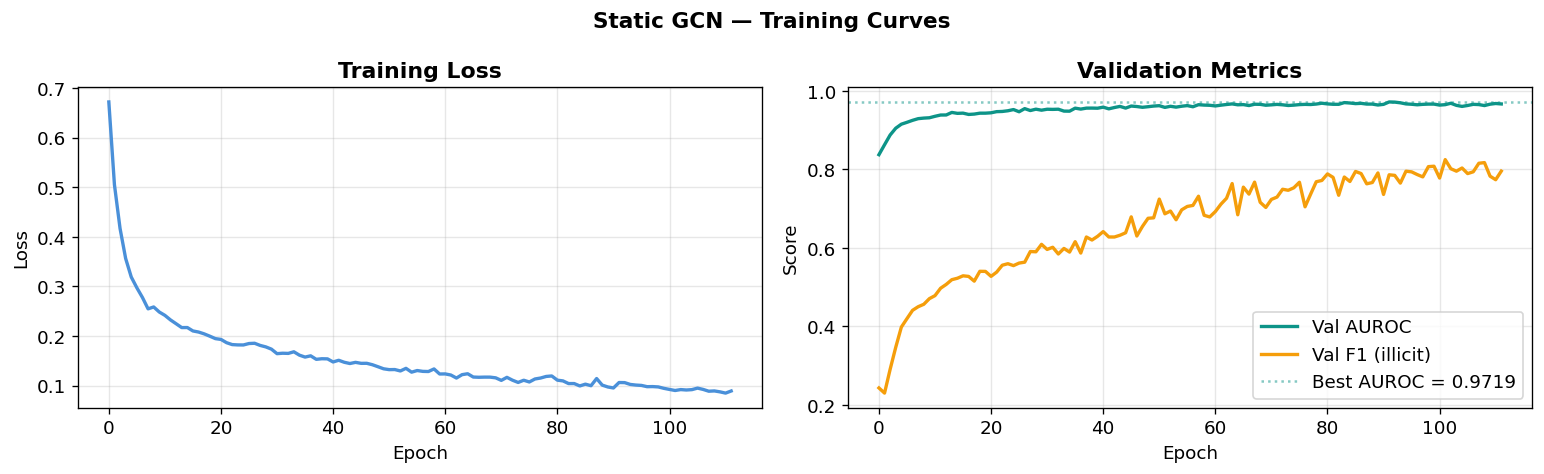

Saved → figures/static_gcn_training_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(len(train_loss_history))

axes[0].plot(epochs_ran, train_loss_history, color='#4A90D9', linewidth=2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, val_auroc_history, color='#0D9488', linewidth=2, label='Val AUROC')
axes[1].plot(epochs_ran, val_f1_history,    color='#F59E0B', linewidth=2, label='Val F1 (illicit)')
axes[1].axhline(best_val_auroc, color='#0D9488', linestyle=':', alpha=0.5,
                label=f'Best AUROC = {best_val_auroc:.4f}')
axes[1].set_title('Validation Metrics', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Static GCN — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'static_gcn_training_curves.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/static_gcn_training_curves.png')

---
## Cell 10 — Load Best Model & Full Test Evaluation

In [12]:
# Load the best checkpoint saved during training
model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'static_gcn_best.pt'),
               map_location=device, weights_only=True)
)
model.eval()
print('Best model loaded.')

# ── Full test evaluation ──────────────────────────────────────────────────────
test_metrics = evaluate(model, TEST_IDX)

print()
print('STATIC GCN — FULL TEST RESULTS  (T37 – T49)')
print('=' * 45)
for k, v in test_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print('=' * 45)
print()
print('NOTE: These aggregate metrics hide drift.')
print('Per-snapshot breakdown in the next cell reveals the T43 collapse.')

Best model loaded.

STATIC GCN — FULL TEST RESULTS  (T37 – T49)
  F1          : 0.6285
  AUROC       : 0.8861
  Precision   : 0.7108
  Recall      : 0.5634

NOTE: These aggregate metrics hide drift.
Per-snapshot breakdown in the next cell reveals the T43 collapse.


---
## Cell 11 — Per-Snapshot Performance Over Test Period

In [13]:
per_snap = evaluate_per_snapshot(model, TEST_IDX)

print('PER-SNAPSHOT RESULTS — T37 to T49')
print(f'{"T":>4}  {"F1":>8}  {"AUROC":>8}  {"Precision":>10}  {"Recall":>8}  Note')
print('-' * 65)
for r in per_snap:
    note = '← SHUTDOWN' if r['time_step'] == SHUTDOWN_STEP else ''
    auroc_str = f"{r['AUROC']:.4f}" if not (isinstance(r['AUROC'], float) and r['AUROC'] != r['AUROC']) else 'nan  '
    print(f"T{r['time_step']:>2}  {r['F1']:>8.4f}  {auroc_str:>8}  "
          f"{r['Precision']:>10.4f}  {r['Recall']:>8.4f}  {note}")

# Compute pre- vs post-shutdown averages
pre  = [r['F1'] for r in per_snap if r['time_step'] < SHUTDOWN_STEP]
post = [r['F1'] for r in per_snap if r['time_step'] > SHUTDOWN_STEP]

print()
print(f'Mean F1 pre-T43  (T37-T42) : {np.mean(pre):.4f}')
print(f'Mean F1 post-T43 (T44-T49) : {np.mean(post):.4f}')
print(f'Drop                       : {np.mean(pre) - np.mean(post):.4f}')

PER-SNAPSHOT RESULTS — T37 to T49
   T        F1     AUROC   Precision    Recall  Note
-----------------------------------------------------------------
T37    0.6000    0.9337      0.6000    0.6000  
T38    0.7845    0.9438      0.7521    0.8198  
T39    0.7471    0.9708      0.6989    0.8025  
T40    0.6702    0.8584      0.8101    0.5714  
T41    0.6881    0.9114      0.7353    0.6466  
T42    0.7678    0.9398      0.8520    0.6987  
T43    0.0000    0.5624      0.0000    0.0000  ← SHUTDOWN
T44    0.0556    0.5822      0.0833    0.0417  
T45    0.0000    0.8285      0.0000    0.0000  
T46    0.0000    0.4359      0.0000    0.0000  
T47    0.0000    0.6731      0.0000    0.0000  
T48    0.1026    0.8955      0.6667    0.0556  
T49    0.0000    0.8285      0.0000    0.0000  

Mean F1 pre-T43  (T37-T42) : 0.7096
Mean F1 post-T43 (T44-T49) : 0.0264
Drop                       : 0.6833


---
## Cell 12 — Drift Visualisation Plot

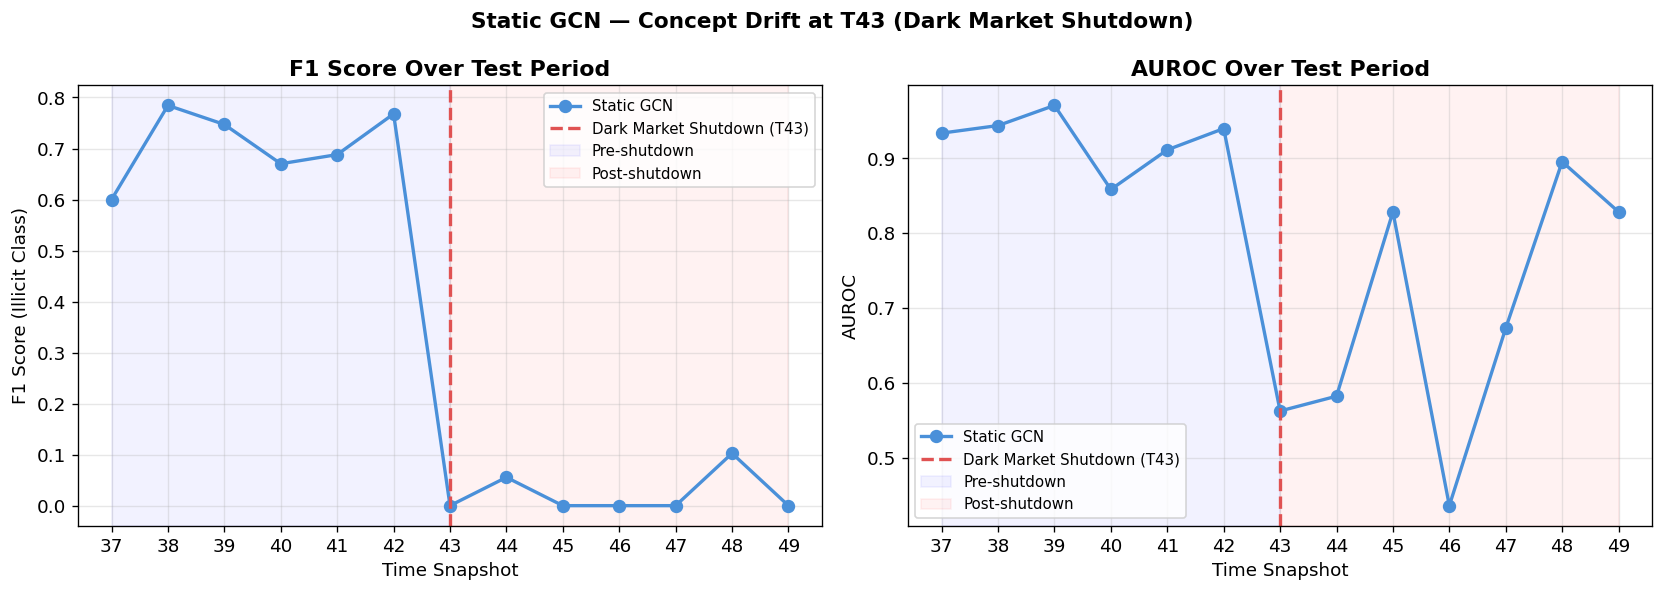

Saved → figures/static_gcn_drift.png


In [14]:
t_steps = [r['time_step'] for r in per_snap]
f1s     = [r['F1']        for r in per_snap]
aurocs  = [r['AUROC']     for r in per_snap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, ylabel, title in [
    (axes[0], f1s,    'F1 Score (Illicit Class)', 'F1 Score Over Test Period'),
    (axes[1], aurocs, 'AUROC',                    'AUROC Over Test Period'),
]:
    ax.plot(t_steps, vals, marker='o', linewidth=2,
            color='#4A90D9', markersize=7, label='Static GCN')
    ax.axvline(x=SHUTDOWN_STEP, color='#E05252', linestyle='--',
               linewidth=2, label=f'Dark Market Shutdown (T{SHUTDOWN_STEP})')
    ax.axvspan(37, SHUTDOWN_STEP, alpha=0.05, color='blue',  label='Pre-shutdown')
    ax.axvspan(SHUTDOWN_STEP, 49, alpha=0.05, color='red',   label='Post-shutdown')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time Snapshot')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xticks(t_steps)

plt.suptitle('Static GCN — Concept Drift at T43 (Dark Market Shutdown)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'static_gcn_drift.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/static_gcn_drift.png')

---
## Cell 13 — Drift Probe
Train on T1–T16 only, then test on T33–T49.  
This exaggerates the drift by using an even shorter training window,  
making the concept drift signal clearer for the paper.

In [15]:
print('DRIFT PROBE — Train: T1–T16  |  Test: T33–T49')
print('=' * 55)

# Fresh model for drift probe
torch.manual_seed(SEED)
drift_model     = StaticGCN().to(device)
drift_optimizer = torch.optim.AdamW(
    drift_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# Train on T1–T16 (no validation / early stopping for probe)
drift_model.train()
for epoch in range(MAX_EPOCHS):
    loss = train_epoch(drift_model, drift_optimizer, DRIFT_TRAIN_IDX)
    if epoch % 50 == 0:
        print(f'  Epoch {epoch:>3}  Loss: {loss:.4f}')

# Per-snapshot evaluation on T33–T49
probe_results = evaluate_per_snapshot(drift_model, DRIFT_TEST_IDX)

print()
print(f'{"T":>4}  {"F1":>8}  {"AUROC":>8}  Note')
print('-' * 40)
for r in probe_results:
    note = '← SHUTDOWN' if r['time_step'] == SHUTDOWN_STEP else ''
    auroc_str = f"{r['AUROC']:.4f}" if not (isinstance(r['AUROC'], float) and r['AUROC'] != r['AUROC']) else 'nan  '
    print(f"T{r['time_step']:>2}  {r['F1']:>8.4f}  {auroc_str:>8}  {note}")

pre_probe  = [r['F1'] for r in probe_results if r['time_step'] < SHUTDOWN_STEP]
post_probe = [r['F1'] for r in probe_results if r['time_step'] > SHUTDOWN_STEP]
print()
print(f'Mean F1 pre-T43  : {np.mean(pre_probe):.4f}')
print(f'Mean F1 post-T43 : {np.mean(post_probe):.4f}')
print(f'Drop             : {np.mean(pre_probe) - np.mean(post_probe):.4f}')

DRIFT PROBE — Train: T1–T16  |  Test: T33–T49
  Epoch   0  Loss: 0.6637
  Epoch  50  Loss: 0.0948
  Epoch 100  Loss: 0.0610
  Epoch 150  Loss: 0.0422

   T        F1     AUROC  Note
----------------------------------------
T33    0.4675    0.9310  
T34    0.2766    0.7794  
T35    0.3583    0.8242  
T36    0.1136    0.7686  
T37    0.2459    0.7677  
T38    0.2128    0.5604  
T39    0.3183    0.8718  
T40    0.2238    0.6804  
T41    0.2687    0.7310  
T42    0.3540    0.7736  
T43    0.0273    0.4710  ← SHUTDOWN
T44    0.0260    0.5935  
T45    0.0000    0.7202  
T46    0.0157    0.8933  
T47    0.0000    0.5255  
T48    0.1277    0.8840  
T49    0.1000    0.9591  

Mean F1 pre-T43  : 0.2840
Mean F1 post-T43 : 0.0449
Drop             : 0.2391


---
## Cell 14 — Drift Probe Plot

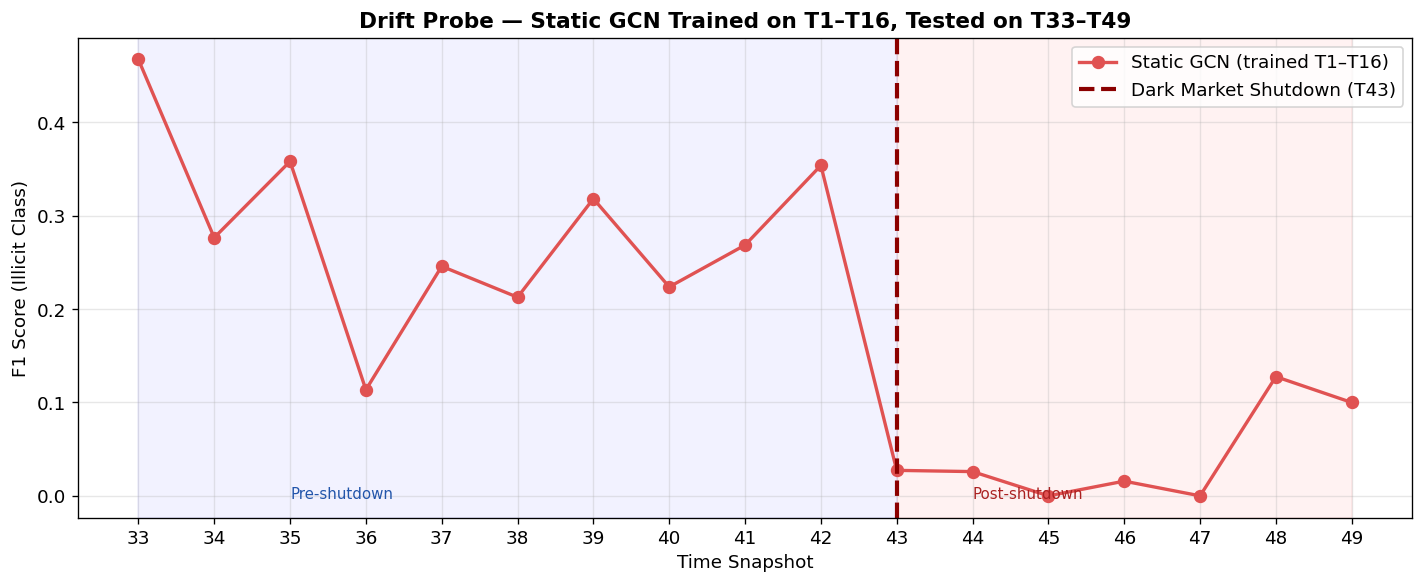

Saved → figures/static_gcn_drift_probe.png


In [16]:
probe_t  = [r['time_step'] for r in probe_results]
probe_f1 = [r['F1']        for r in probe_results]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(probe_t, probe_f1, marker='o', linewidth=2,
        color='#E05252', markersize=7, label='Static GCN (trained T1–T16)')
ax.axvline(x=SHUTDOWN_STEP, color='darkred', linestyle='--',
           linewidth=2.5, label=f'Dark Market Shutdown (T{SHUTDOWN_STEP})')
ax.axvspan(33, SHUTDOWN_STEP, alpha=0.05, color='blue')
ax.axvspan(SHUTDOWN_STEP, 49, alpha=0.05, color='red')
ax.text(35, ax.get_ylim()[0]+0.02, 'Pre-shutdown', fontsize=9, color='#2255AA')
ax.text(44, ax.get_ylim()[0]+0.02, 'Post-shutdown', fontsize=9, color='#AA2222')

ax.set_title('Drift Probe — Static GCN Trained on T1–T16, Tested on T33–T49',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Snapshot')
ax.set_ylabel('F1 Score (Illicit Class)')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(probe_t)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'static_gcn_drift_probe.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/static_gcn_drift_probe.png')

---
### Multi-seed robustness (S3 / G2)

Re-train the Static GCN from scratch under 5 seeds and report **mean ± std** for every
headline metric. The seed-42 checkpoint saved above stays the canonical model used by
the SHAP notebook; this harness only quantifies variance and is saved to
`results_by_seed.json`.

In [17]:
SEEDS = [42, 7, 13, 21, 100]

def run_single_seed(seed):
    """Fresh train + early-stop (val AUROC) + test eval for one seed. Returns metrics."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    mdl = StaticGCN().to(device)
    opt = torch.optim.AdamW(mdl.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_auroc, best_state, patience = 0.0, None, 0
    for epoch in range(MAX_EPOCHS):
        train_epoch(mdl, opt, TRAIN_IDX)
        va = evaluate(mdl, VAL_IDX)['AUROC']
        if not np.isnan(va) and va > best_auroc:
            best_auroc = va
            best_state = {k: v.detach().cpu().clone() for k, v in mdl.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    if best_state is not None:
        mdl.load_state_dict(best_state)

    test = evaluate(mdl, TEST_IDX)
    psnap = evaluate_per_snapshot(mdl, TEST_IDX)
    pre  = [r['F1'] for r in psnap if r['time_step'] < SHUTDOWN_STEP and r['time_step'] >= 37]
    post = [r['F1'] for r in psnap if r['time_step'] > SHUTDOWN_STEP]
    return {
        'seed'             : seed,
        'best_val_auroc'   : round(float(best_auroc), 4),
        'test_F1'          : round(float(test['F1']), 4),
        'test_AUROC'       : round(float(test['AUROC']), 4),
        'test_Precision'   : round(float(test['Precision']), 4),
        'test_Recall'      : round(float(test['Recall']), 4),
        'pre_t43_mean_f1'  : round(float(np.mean(pre)), 4),
        'post_t43_mean_f1' : round(float(np.mean(post)), 4),
        'f1_drop'          : round(float(np.mean(pre) - np.mean(post)), 4),
    }

print('MULTI-SEED RUN — Static GCN')
print('=' * 70)
per_seed = []
for s in SEEDS:
    r = run_single_seed(s)
    per_seed.append(r)
    print(f"  seed {s:>3} | valAUROC {r['best_val_auroc']:.4f} | testF1 {r['test_F1']:.4f}"
          f" | pre {r['pre_t43_mean_f1']:.4f} | post {r['post_t43_mean_f1']:.4f}"
          f" | drop {r['f1_drop']:.4f}")

def _ms(key):
    vals = [r[key] for r in per_seed]
    return float(np.mean(vals)), float(np.std(vals))

print()
print(f'{"Metric":<18}{"mean ± std":>20}')
print('-' * 38)
seed_summary = {'seeds': SEEDS, 'per_seed': per_seed, 'mean_std': {}}
for key in ['test_F1', 'test_AUROC', 'test_Precision', 'test_Recall',
            'pre_t43_mean_f1', 'post_t43_mean_f1', 'f1_drop']:
    mu, sd = _ms(key)
    seed_summary['mean_std'][key] = {'mean': round(mu, 4), 'std': round(sd, 4)}
    print(f'{key:<18}{mu:>12.4f} ± {sd:.4f}')

seed_path = os.path.join(PROCESSED_DIR, 'static_gcn_results_by_seed.json')
with open(seed_path, 'w') as f:
    json.dump(seed_summary, f, indent=2)
print(f'\nSaved → {seed_path}')

MULTI-SEED RUN — Static GCN
  seed  42 | valAUROC 0.9719 | testF1 0.6285 | pre 0.7096 | post 0.0264 | drop 0.6833
  seed   7 | valAUROC 0.9659 | testF1 0.5822 | pre 0.6624 | post 0.0190 | drop 0.6434
  seed  13 | valAUROC 0.9729 | testF1 0.6026 | pre 0.6701 | post 0.0108 | drop 0.6594
  seed  21 | valAUROC 0.9636 | testF1 0.5957 | pre 0.6864 | post 0.0183 | drop 0.6681
  seed 100 | valAUROC 0.9672 | testF1 0.6081 | pre 0.6910 | post 0.0000 | drop 0.6910

Metric                      mean ± std
--------------------------------------
test_F1                 0.6034 ± 0.0152
test_AUROC              0.8872 ± 0.0050
test_Precision          0.7250 ± 0.0623
test_Recall             0.5210 ± 0.0327
pre_t43_mean_f1         0.6839 ± 0.0166
post_t43_mean_f1        0.0149 ± 0.0089
f1_drop                 0.6690 ± 0.0170

Saved → /content/drive/MyDrive/Capstone/Testing/data/processed/static_gcn_results_by_seed.json


---
## Cell 15 — Save Outputs for Phase 4 (SHAP)

In [18]:
# Save predictions and embeddings for all test snapshots (seed-42 canonical model)
# These will be loaded by the SHAP notebook in Phase 4
model.eval()
all_outputs = {}

with torch.no_grad():
    for i in TEST_IDX:
        data = snapshots[i].to(device)
        out, emb = model(data.x, data.edge_index)
        probs = torch.softmax(out, dim=1)[:, 1]

        all_outputs[i] = {
            'time_step'  : snapshots[i].time_step.item(),
            'preds'      : out.argmax(dim=1).cpu(),
            'probs'      : probs.cpu(),
            'embeddings' : emb.cpu(),
            'y_true'     : data.y.cpu(),
            'label_mask' : data.label_mask.cpu(),
        }

output_path = os.path.join(PROCESSED_DIR, 'static_gcn_outputs.pt')
torch.save(all_outputs, output_path)
print(f'Outputs saved → {output_path}')

# True per-snapshot pre/post-T43 means from the MAIN test run (S2 — top-level fields
# so notebook 03 stops hardcoding / mislabelling Static's pre-T43 F1).
main_pre  = [r['F1'] for r in per_snap if 37 <= r['time_step'] < SHUTDOWN_STEP]  # T37–T42
main_post = [r['F1'] for r in per_snap if r['time_step'] > SHUTDOWN_STEP]         # T44–T49

summary = {
    'model'            : 'Static GCN',
    'architecture'     : f'{IN_CHANNELS} → {HIDDEN1} → {HIDDEN2} → 2',
    'graph_standard'   : 'Weber (unknown nodes kept, label-masked loss)',
    'train_snapshots'  : 'T1-T34',
    'val_snapshots'    : 'T35-T36',
    'test_snapshots'   : 'T37-T49',
    'best_val_auroc'   : round(best_val_auroc, 4),
    'test_metrics'     : {k: round(v, 4) for k, v in test_metrics.items()},
    'per_snapshot'     : per_snap,
    # S2 — true main-test pre/post-T43 means (top-level, unambiguous)
    'pre_t43_mean_f1'  : round(float(np.mean(main_pre)), 4),
    'post_t43_mean_f1' : round(float(np.mean(main_post)), 4),
    'f1_drop'          : round(float(np.mean(main_pre) - np.mean(main_post)), 4),
    'drift_probe'      : {
        'train' : 'T1-T16',
        'test'  : 'T33-T49',
        'mean_f1_pre_t43'  : round(float(np.mean(pre_probe)), 4),
        'mean_f1_post_t43' : round(float(np.mean(post_probe)), 4),
        'f1_drop'          : round(float(np.mean(pre_probe) - np.mean(post_probe)), 4),
    }
}

summary_path = os.path.join(PROCESSED_DIR, 'static_gcn_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary saved  → {summary_path}')
print(f"  pre-T43 mean F1 (T37-T42) : {summary['pre_t43_mean_f1']}")
print(f"  post-T43 mean F1 (T44-T49): {summary['post_t43_mean_f1']}")

print()
print('PHASE 2 COMPLETE')
print('Next step: Phase 3 — EvolveGCN-H training')

Outputs saved → /content/drive/MyDrive/Capstone/Testing/data/processed/static_gcn_outputs.pt
Summary saved  → /content/drive/MyDrive/Capstone/Testing/data/processed/static_gcn_summary.json
  pre-T43 mean F1 (T37-T42) : 0.7096
  post-T43 mean F1 (T44-T49): 0.0264

PHASE 2 COMPLETE
Next step: Phase 3 — EvolveGCN-H training
